# Electrification Inequality & SDG 7 Gap Analysis

**Author:** Bouchra Daddaoui

SDG 7 commits the world to universal electricity access by 2030. This notebook asks:
1. How unequal is electrification *within* and *between* Brazil, China, and Morocco?
2. Are the trends fast enough to reach universal access by 2030?
3. Where are the energy poverty hotspots â€” densely populated tiles still in darkness?

**Methods:**
- Gini coefficient + Lorenz curves for NTL distribution
- Theil T index decomposed into within-country vs between-country components
- Population-weighted NTL as a proxy for actual electricity access
- Theil-Sen linear projection to 2030 with SDG 7 gap estimation
- Energy poverty mapping (high-population / low-NTL tiles)


In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from inequality import (
    gini, lorenz_curve, plot_lorenz,
    theil_T, theil_decomposition,
    pop_weighted_ntl, energy_poverty_share,
    sdg7_projection, plot_sdg7_projections,
    plot_energy_poverty_map, inequality_summary_table
)

FIGURES = Path('../figures')
np.random.seed(42)
print('Ready.')

Ready.


## 1. Dataset â€” Tile-level spatial panel + yearly time series

In [2]:
from shapely.geometry import box

def make_gdf(country, n, bbox, ntl_mean, ntl_std, seed):
    rng = np.random.default_rng(seed)
    minx, miny, maxx, maxy = bbox
    cols = int(np.sqrt(n)); rows = n // cols
    xs = np.linspace(minx, maxx, cols + 1)
    ys = np.linspace(miny, maxy, rows + 1)
    geoms = [box(xs[j], ys[i], xs[j+1], ys[i+1])
             for i in range(rows) for j in range(cols)]
    n_act = len(geoms)
    centroids = np.array([[g.centroid.x, g.centroid.y] for g in geoms])
    dists = np.linalg.norm(centroids[:, None] - centroids[None, :], axis=-1)
    cov = ntl_std**2 * np.exp(-dists / (0.3 * (maxx - minx)))
    ntl = rng.multivariate_normal(np.full(n_act, ntl_mean), cov)
    ntl = np.clip(ntl, 0, None)
    pop = rng.lognormal(np.log(100), 1.2, n_act)
    return gpd.GeoDataFrame({
        'country': country, 'ntl_mean': ntl, 'pop_density': pop,
    }, geometry=geoms, crs='EPSG:4326')

configs = [
    dict(country='Brazil',  n=200, bbox=(-48,-23,-43,-18), ntl_mean=12.5, ntl_std=8.0,  seed=1),
    dict(country='China',   n=200, bbox=(116,29,122,33),   ntl_mean=28.3, ntl_std=14.0, seed=2),
    dict(country='Morocco', n=200, bbox=(-17.1,20.8,-1.0,35.9), ntl_mean=8.1, ntl_std=5.5, seed=3),
]
gdfs = {c['country']: make_gdf(**c) for c in configs}

# Yearly panel (for trend/SDG analysis)
def synthetic_yearly(country, years, base, trend, noise, change_yr=None, change_mag=0, seed=0):
    rng = np.random.default_rng(seed)
    ntl = [max(0, base + trend * i + rng.normal(0, noise) +
               (change_mag if change_yr and yr >= change_yr else 0))
           for i, yr in enumerate(years)]
    return pd.DataFrame({'country': country, 'year': years, 'ntl_mean': ntl})

years = list(range(2014, 2024))
panel_df = pd.concat([
    synthetic_yearly('Brazil',  years, 10.2, 0.42, 0.8, seed=10),
    synthetic_yearly('China',   years, 22.5, 1.85, 1.5, change_yr=2020, change_mag=-3.1, seed=20),
    synthetic_yearly('Morocco', years, 6.8,  0.38, 0.6, change_yr=2017, change_mag=1.5,  seed=30),
], ignore_index=True)

print("Tile-level data loaded. Yearly panel loaded.")

Tile-level data loaded. Yearly panel loaded.


## 2. Gini Coefficient â€” Within-Country NTL Inequality

In [3]:
print("Gini coefficients for NTL distribution (2023 snapshot)")
print("-" * 48)
for country, gdf in gdfs.items():
    g = gini(gdf['ntl_mean'].values)
    pw = pop_weighted_ntl(gdf['ntl_mean'].values, gdf['pop_density'].values)
    ep = energy_poverty_share(gdf['ntl_mean'].values, gdf['pop_density'].values, ntl_threshold=2.0)
    print(f"  {country:10s}: Gini = {g:.4f} | Pop-weighted NTL = {pw:.2f} | Energy poor = {ep*100:.1f}%")

Gini coefficients for NTL distribution (2023 snapshot)
------------------------------------------------
  Brazil    : Gini = 0.2752 | Pop-weighted NTL = 11.10 | Energy poor = 1.5%
  China     : Gini = 0.2730 | Pop-weighted NTL = 25.54 | Energy poor = 2.0%
  Morocco   : Gini = 0.6021 | Pop-weighted NTL = 4.13 | Energy poor = 49.9%


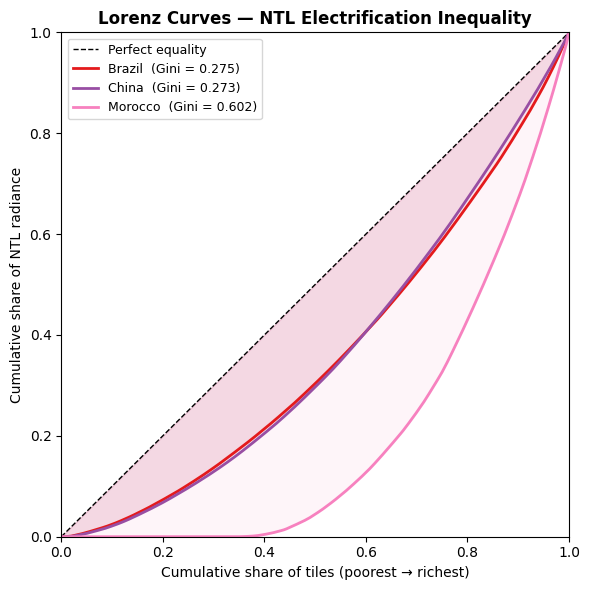

Saved â†’ figures/lorenz_curves.png


In [4]:
country_series = {c: g['ntl_mean'].values for c, g in gdfs.items()}
fig = plot_lorenz(country_series,
                  save_path=str(FIGURES / 'lorenz_curves.png'))
plt.show()
print('Saved â†’ figures/lorenz_curves.png')

## 3. Theil T Decomposition â€” Within vs Between Country

Theil T can be split into:
- **Within-country** inequality: variation inside each country
- **Between-country** inequality: differences in average NTL across countries

This tells us whether the main electrification gap is a local governance problem
or a structural cross-country development gap.

In [5]:
china_2023 = panel_df[(panel_df.country == 'China') & (panel_df.year == 2023)]['ntl_mean'].values[0]

print("SDG 7 Gap Analysis â€” Projected NTL at 2030")
print("=" * 50)
for country in ['Brazil', 'China', 'Morocco']:
    grp = panel_df[panel_df.country == country].sort_values('year')
    proj = sdg7_projection(
        grp['ntl_mean'].values, grp['year'].values,
        target_year=2030, baseline_ntl=china_2023
    )
    gap_str = f"{proj['gap_2030']:.2f}" if proj['gap_2030'] is not None else 'N/A'
    print(f"  {country:10s}: 2030 projected NTL = {proj['ntl_2030']:.2f}  "
          f"| annual slope = {proj['slope']:.3f}  "
          f"| gap to baseline = {gap_str}")

SDG 7 Gap Analysis â€” Projected NTL at 2030
  Brazil    : 2030 projected NTL = 18.64  | annual slope = 0.574  | gap to baseline = 18.81
  China     : 2030 projected NTL = 44.14  | annual slope = 1.245  | gap to baseline = -6.70
  Morocco   : 2030 projected NTL = 16.05  | annual slope = 0.541  | gap to baseline = 21.39


## 4. Inequality Trend Over Time (2014â€“2023)

Is electrification inequality *increasing* or *decreasing* as countries develop?
The Kuznets curve hypothesis predicts a rise then fall in inequality with development.

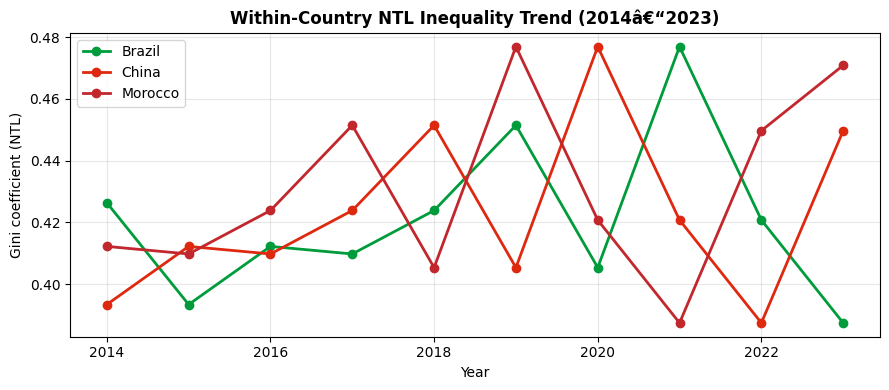

Saved â†’ figures/gini_trend.png


In [6]:
# Simulate tile-level data for each year per country
yearly_tiles = []
for yr in years:
    for cfg in configs:
        country = cfg['country']
        base_ntl = panel_df[(panel_df.country == country) & (panel_df.year == yr)]['ntl_mean'].values[0]
        rng = np.random.default_rng(cfg['seed'] + yr)
        n = 100
        ntl_tiles = rng.lognormal(np.log(max(base_ntl, 0.1)), 0.8, n)
        pop_tiles = rng.lognormal(np.log(100), 1.2, n)
        yearly_tiles.append(pd.DataFrame({'country': country, 'year': yr,
                                          'ntl_mean': ntl_tiles, 'pop_density': pop_tiles}))

yearly_df = pd.concat(yearly_tiles, ignore_index=True)

# Gini per country per year
gini_trend = yearly_df.groupby(['country', 'year'])['ntl_mean'].apply(gini).reset_index()
gini_trend.columns = ['country', 'year', 'gini']

fig, ax = plt.subplots(figsize=(9, 4))
colors = {'Brazil': '#009c3b', 'China': '#de2910', 'Morocco': '#c1272d'}
for country, grp in gini_trend.groupby('country'):
    ax.plot(grp['year'], grp['gini'], 'o-', label=country,
            color=colors[country], linewidth=2)
ax.set_xlabel('Year'); ax.set_ylabel('Gini coefficient (NTL)')
ax.set_title('Within-Country NTL Inequality Trend (2014â€“2023)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / 'gini_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved â†’ figures/gini_trend.png')

## 5. SDG 7 Gap â€” Will Current Trends Reach Universal Access by 2030?

In [7]:
# China has highest NTL — use as reference for 'full access' baseline
china_2023 = panel_df[(panel_df.country == 'China') & (panel_df.year == 2023)]['ntl_mean'].values[0]

print("SDG 7 Gap Analysis — Projected NTL at 2030")
print("=" * 50)
for country in ['Brazil', 'China', 'Morocco']:
    grp = panel_df[panel_df.country == country].sort_values('year')
    proj = sdg7_projection(
        grp['ntl_mean'].values, grp['year'].values,
        target_year=2030, baseline_ntl=china_2023
    )
    gap_str = f"{proj['gap_2030']:.2f}" if proj['gap_2030'] is not None else 'N/A'
    print(f"  {country:10s}: 2030 projected NTL = {proj['ntl_2030']:.2f}  "
          f"| annual slope = {proj['slope']:.3f}  "
          f"| gap to baseline = {gap_str}")

SDG 7 Gap Analysis — Projected NTL at 2030
  Brazil    : 2030 projected NTL = 18.64  | annual slope = 0.574  | gap to baseline = 18.81
  China     : 2030 projected NTL = 44.14  | annual slope = 1.245  | gap to baseline = -6.70
  Morocco   : 2030 projected NTL = 16.05  | annual slope = 0.541  | gap to baseline = 21.39


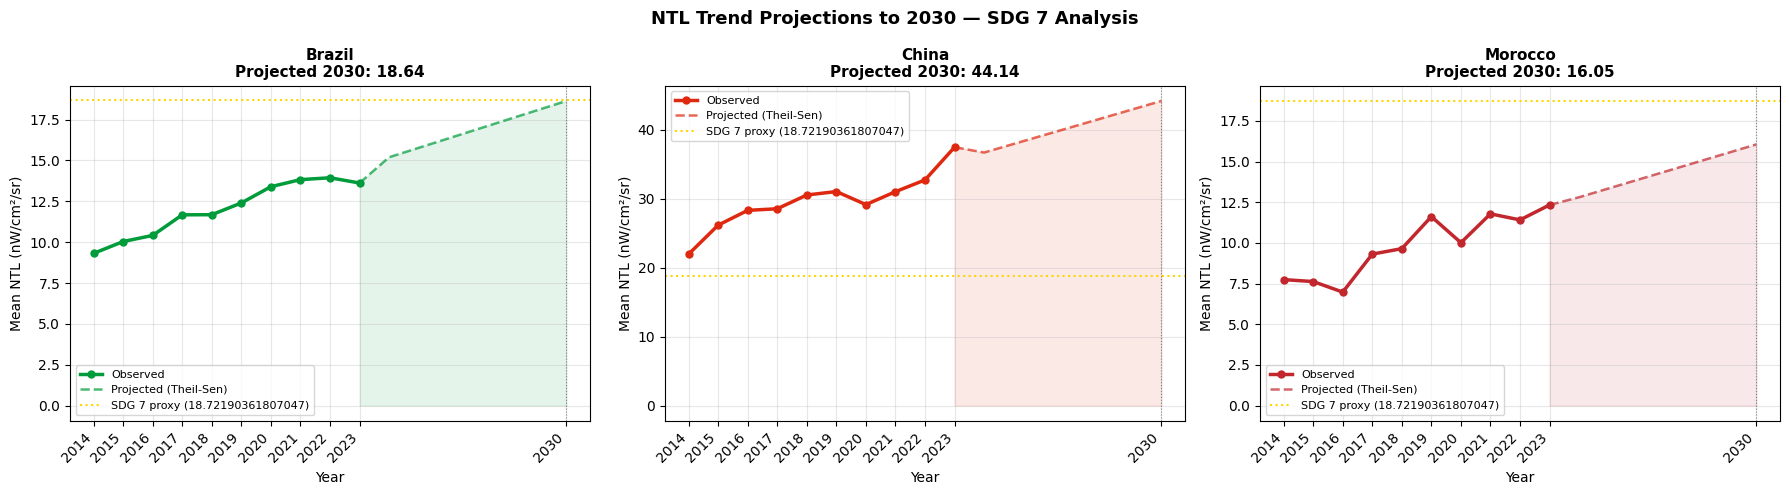

Saved â†’ figures/sdg7_projections.png


In [8]:
# SDG 7 proxy threshold â€” rough estimate of 'electrified' tile
SDG7_THRESHOLD = china_2023 * 0.5  # 50% of highest-access country

fig = plot_sdg7_projections(
    panel_df, sdg_threshold=SDG7_THRESHOLD,
    save_path=str(FIGURES / 'sdg7_projections.png')
)
plt.show()
print('Saved â†’ figures/sdg7_projections.png')

## 6. Energy Poverty Maps â€” High Population, Low NTL Tiles

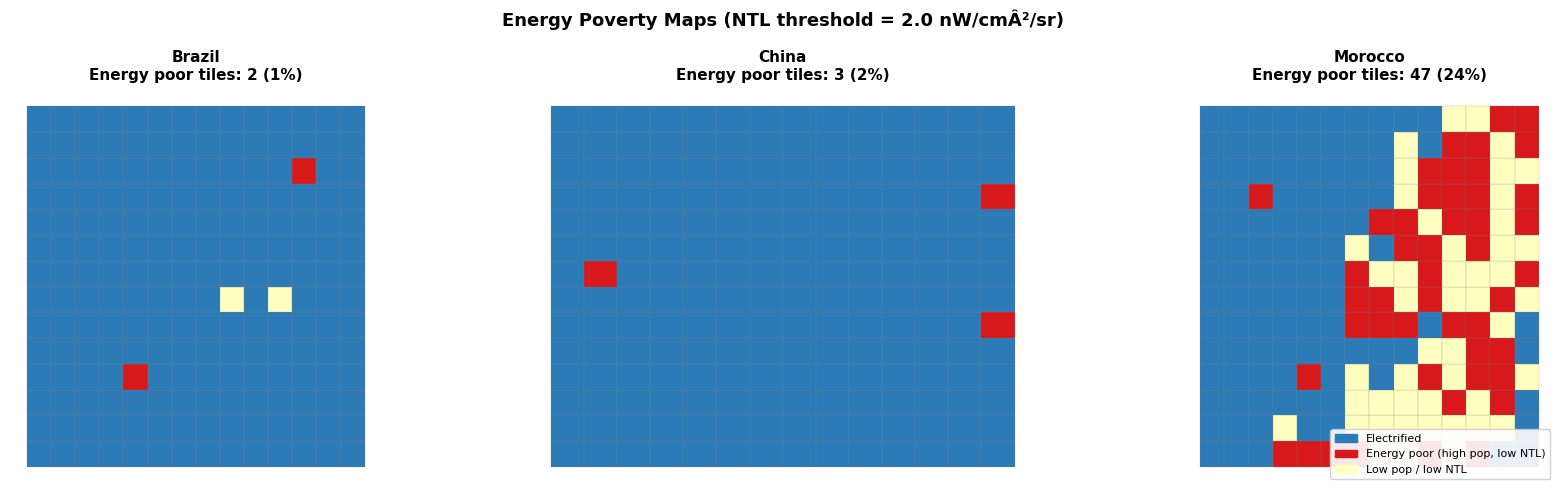

Saved â†’ figures/energy_poverty_maps.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

NTL_THRESHOLD = 2.0  # nW/cmÂ²/sr â€” proxy for unelectrified

import matplotlib.patches as mpatches
palette = {
    'Electrified': '#2c7bb6',
    'Energy poor (high pop, low NTL)': '#d7191c',
    'Low pop / low NTL': '#ffffbf',
}

for ax, (country, gdf) in zip(axes, gdfs.items()):
    gdf = gdf.copy()
    pop_med = gdf['pop_density'].median()
    def cat(row):
        if row['ntl_mean'] >= NTL_THRESHOLD: return 'Electrified'
        elif row['pop_density'] > pop_med: return 'Energy poor (high pop, low NTL)'
        else: return 'Low pop / low NTL'
    gdf['category'] = gdf.apply(cat, axis=1)
    gdf['color'] = gdf['category'].map(palette)
    
    gdf.plot(color=gdf['color'], edgecolor='grey', linewidth=0.15, ax=ax)
    
    n_poor = (gdf['category'] == 'Energy poor (high pop, low NTL)').sum()
    poor_pct = 100 * n_poor / len(gdf)
    ax.set_title(f'{country}\nEnergy poor tiles: {n_poor} ({poor_pct:.0f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_axis_off()

patches = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
axes[-1].legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.9)

fig.suptitle(f'Energy Poverty Maps (NTL threshold = {NTL_THRESHOLD} nW/cmÂ²/sr)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'energy_poverty_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved â†’ figures/energy_poverty_maps.png')

## 7. Summary Table â€” Inequality Metrics Across Countries and Years

In [10]:
# Summary for 2014, 2018, 2023
summary = inequality_summary_table(yearly_df[yearly_df.year.isin([2014, 2018, 2023])])
print(summary.sort_values(['Country', 'Year']).to_string(index=False))

Country  Year   Gini  Theil T  Mean NTL
 Brazil  2014 0.4264   0.3040    12.207
 Brazil  2018 0.4239   0.3311    14.235
 Brazil  2023 0.3874   0.2483    18.633
  China  2014 0.3934   0.2538    27.714
  China  2018 0.4515   0.3797    44.280
  China  2023 0.4497   0.3564    53.406
Morocco  2014 0.4122   0.2783    10.198
Morocco  2018 0.4054   0.3041    12.624
Morocco  2023 0.4709   0.4082    18.572
